In [2]:
# %pip install catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.1/102.4 MB 2.7 MB/s eta 0:00:38
   ---------------------------------------- 0.3/102.4 MB 4.3 MB/s eta 0:00:24
   ---------------------------------------- 1.0/102.4 MB 9.0 MB/s eta 0:00:12
    --------------------------------------- 2.2/102.4 MB 14.1 MB/s eta 0:00:08
   - -------------------------------------- 3.3/102.4 MB 16.4 MB/s eta 0:00:07
   - -------------------------------------- 3.9/102.4 MB 15.7 MB/s eta 0:00:07
   - -------------------------------------- 4.5/102.4 MB 15.3 MB/s eta 0:00:07
   -- ------------------------------------- 5.2/102.4 MB 15.0 MB/s eta 0:00:07
   -- ------------------------------------- 5.7/102.4 MB 14.7 MB/s eta 0:00:07
   -- ------------------------------------- 6.4/102.4 MB 14.6 MB/s eta 0:00:07
   -- ------------------------------------- 7.0/102.4 MB 14.4 MB/s eta 0:00:07



[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#  NSL-KDD Full Pipeline WITHOUT get_dummies()
# Using CatBoost + SMOTE

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# ---------- Load Dataset ----------
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'class','difficulty'
]

train_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTrain+.txt", header=None, names=column_names)
test_df  = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTest+.txt", header=None, names=column_names)

# Remove leakage column 
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

# Create binary target labels 
train_df["attack_binary"] = (train_df["class"] != "normal").astype(int)
test_df["attack_binary"]  = (test_df["class"] != "normal").astype(int)

# Split X & y 
X_train_raw = train_df.drop(["class","attack_binary"], axis=1)
y_train = train_df["attack_binary"]

X_test_raw = test_df.drop(["class","attack_binary"], axis=1)
y_test = test_df["attack_binary"]

# Identify categorical column names 
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

# Label Encode Categorical Columns (Only for SMOTE) 
le_dict = {}
X_train_for_smote = X_train_raw.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_for_smote[col] = le.fit_transform(X_train_for_smote[col])
    le_dict[col] = le  # store encoder if needed later

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_for_smote, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.value_counts())


# Define categorical feature indices for CatBoost 
cat_indices = [X_train_raw.columns.get_loc(col) for col in categorical_cols]


# Train CatBoost Model 
cat_model = CatBoostClassifier(
    iterations=600,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=False
)

cat_model.fit(X_train_bal, y_train_bal, cat_features=cat_indices)


# Evaluate on ORIGINAL Test Data
preds = cat_model.predict(X_test_raw)

print("\n===== CATBOOST RESULTS (NO OHE) =====")
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(classification_report(y_test, preds, target_names=["Normal", "Attack"]))


After SMOTE: (134686, 41) attack_binary
0    67343
1    67343
Name: count, dtype: int64


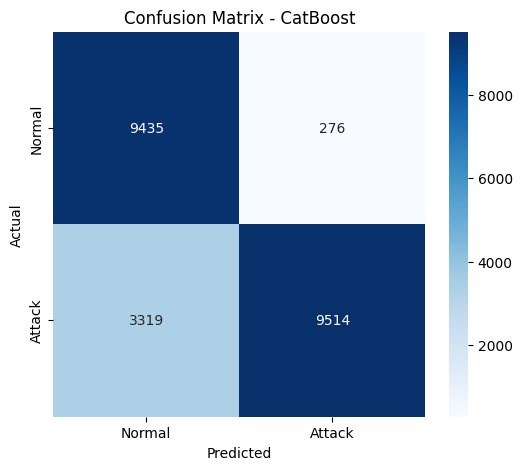

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CatBoost")
plt.show()


In [10]:
import joblib

joblib.dump(cat_model, "catboost_nslkdd_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [1]:
import joblib

# Load model
cat_model_loaded = joblib.load("catboost_nslkdd_model.pkl")

print("Model loaded successfully!")


Model loaded successfully!


In [5]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np


def get_metrics(model, X, y):
    preds = model.predict(X)

    try:
        probs = model.predict_proba(X)[:, 1]
    except:
        probs = None

    accuracy = accuracy_score(y, preds)
    sensitivity = recall_score(y, preds)             # recall for class 1
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)
    f1 = f1_score(y, preds)

    auc = roc_auc_score(y, probs) if probs is not None else np.nan

    return accuracy, sensitivity, specificity, f1, auc


# TRAIN METRICS
tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(cat_model_loaded, X_train_bal, y_train_bal)

train_df = pd.DataFrame([[
    f"{tr_acc*100:.2f}%",
    f"{tr_sens*100:.2f}%",
    f"{tr_spec*100:.2f}%",
    f"{tr_f1*100:.2f}%",
    f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
]], columns=["Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"])

print("Metrics for Catboost Model")
print("\n TRAIN METRICS")
display(train_df)


# TEST METRICS
te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(cat_model_loaded, X_test_raw, y_test)

test_df = pd.DataFrame([[
    f"{te_acc*100:.2f}%",
    f"{te_sens*100:.2f}%",
    f"{te_spec*100:.2f}%",
    f"{te_f1*100:.2f}%",
    f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
]], columns=["Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"])

print("\n TEST METRICS")
display(test_df)


Metrics for Catboost Model

 TRAIN METRICS


,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,99.95%,99.94%,99.96%,99.95%,1.0000



 TEST METRICS


,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,84.05%,74.14%,97.16%,84.11%,0.9102



 MULTI-CLASS CATBOOST RESULTS 
Accuracy: 0.7891234918381831

Classification Report:

              precision    recall  f1-score   support

         dos       0.95      0.82      0.88      7460
      normal       0.70      0.97      0.82      9711
       probe       0.81      0.72      0.76      2421
         r2l       0.98      0.17      0.28      2752
         u2r       0.49      0.10      0.17       200

    accuracy                           0.79     22544
   macro avg       0.79      0.56      0.58     22544
weighted avg       0.83      0.79      0.76     22544



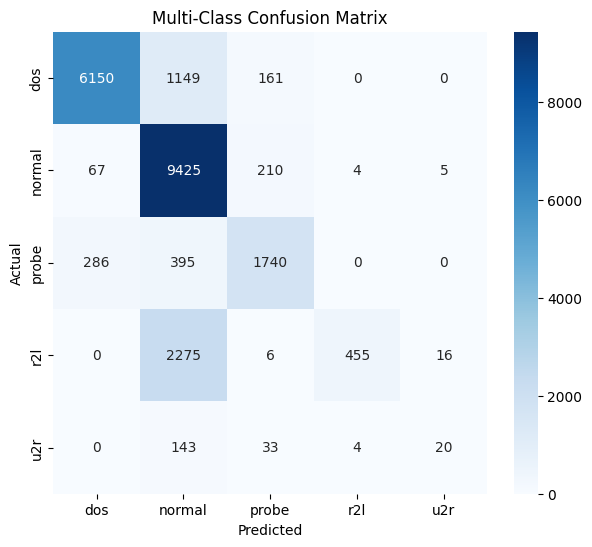

Model Saved Successfully!
Model Loaded Successfully!


In [13]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Load Dataset
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'class','difficulty'
]

train_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTrain+.txt",
                       header=None, names=column_names)
test_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTest+.txt",
                      header=None, names=column_names)

# Remove leakage column
train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

# Attack mapping to 5 categories
def map_attack_type(label):
    if label == "normal":
        return "normal"
    elif label in ["apache2","back","land","neptune","mailbomb","pod","processtable",
                   "smurf","teardrop","udpstorm","worm"]:
        return "dos"
    elif label in ["ipsweep","mscan","nmap","portsweep","saint","satan"]:
        return "probe"
    elif label in ["ftp_write","guess_passwd","http_tunnel","imap","multihop",
                   "named","phf","sendmail","snmpgetattack","snmpguess","spy",
                   "warezclient","warezmaster","xlock","xsnoop"]:
        return "r2l"
    else:
        return "u2r"

train_df["attack_class"] = train_df["class"].apply(map_attack_type)
test_df["attack_class"] = test_df["class"].apply(map_attack_type)

# Encode target labels
label_y = LabelEncoder()
y_train = label_y.fit_transform(train_df["attack_class"])
y_test  = label_y.transform(test_df["attack_class"])

# Prepare features
X_train_raw = train_df.drop(["class", "attack_class"], axis=1)
X_test_raw  = test_df.drop(["class", "attack_class"], axis=1)

categorical_cols = ['protocol_type', 'service', 'flag']

# Ensure correct types
for col in X_train_raw.columns:
    if col in categorical_cols:
        X_train_raw[col] = X_train_raw[col].astype(str)
        X_test_raw[col]  = X_test_raw[col].astype(str)
    else:
        X_train_raw[col] = pd.to_numeric(X_train_raw[col], errors='coerce')
        X_test_raw[col]  = pd.to_numeric(X_test_raw[col], errors='coerce')

# Fill NaN
X_train_raw.fillna(0, inplace=True)
X_test_raw.fillna(0, inplace=True)

# Scale numeric features
scaler = StandardScaler()
numeric_cols = [c for c in X_train_raw.columns if c not in categorical_cols]

X_train_scaled = X_train_raw.copy()
X_test_scaled  = X_test_raw.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test_raw[numeric_cols])

# Categorical indices
cat_indices = [X_train_scaled.columns.get_loc(c) for c in categorical_cols]

# Improved CatBoost Model (Faster + Higher Accuracy)
model = CatBoostClassifier(
    iterations=600,
    depth=7,
    learning_rate=0.07,
    loss_function='MultiClass',
    auto_class_weights="Balanced",
    one_hot_max_size=10,
    border_count=128,
    l2_leaf_reg=3,
    early_stopping_rounds=50,
    verbose=False
)

# Train model
model.fit(X_train_scaled, y_train, cat_features=cat_indices)

# Predict
preds = model.predict(X_test_scaled).astype(int)

# Results
print("\n MULTI-CLASS CATBOOST RESULTS ")
print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=label_y.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_y.classes_,
            yticklabels=label_y.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class Confusion Matrix")
plt.show()

# Save model
joblib.dump(model, "catboost_multiclass_nslkdd3.pkl")
print("Model Saved Successfully!")

# Load model
loaded = joblib.load("catboost_multiclass_nslkdd3.pkl")
print("Model Loaded Successfully!")


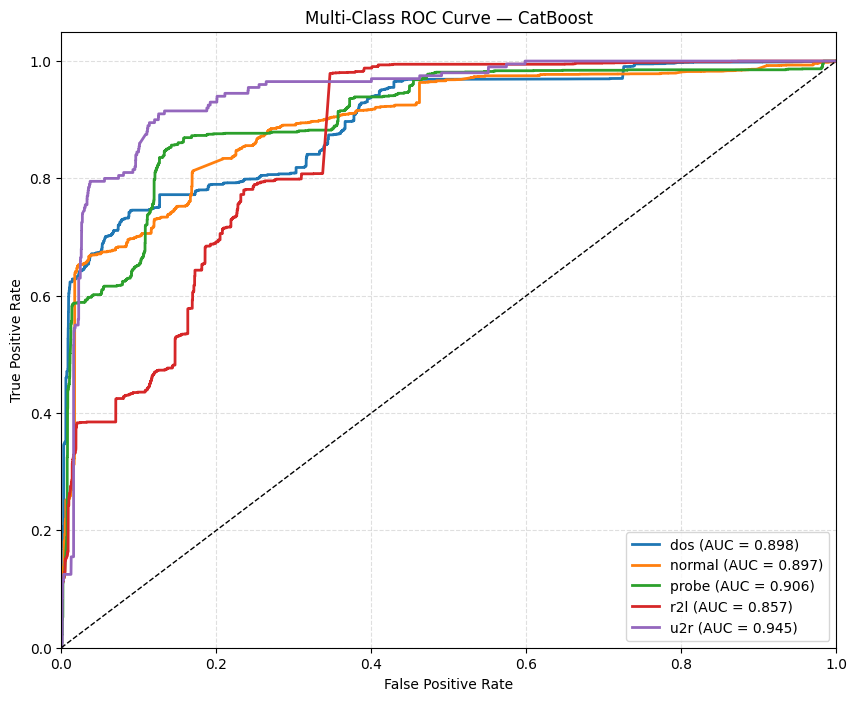

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# 1. Binarize labels for multi-class ROC
class_names = label_y.classes_
n_classes = len(class_names)

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# CatBoost predict_proba
y_proba = model.predict_proba(X_test_scaled)


# 2. Calculate ROC + AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


# 3. Plot ROC curves
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i], lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve — CatBoost")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()
